# **RAG infernce with a floor plan dataset** 🏠

Working on langchain with Json files:

https://python.langchain.com/docs/how_to/document_loader_json/

https://python.langchain.com/docs/integrations/document_loaders/json/



---
## Setup langchain


In [ ]:
import os

from langchain_community.document_loaders import JSONLoader
from langchain_text_splitters import CharacterTextSplitter
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

import json
from pathlib import Path
from pprint import pprint

from dotenv import load_dotenv

continue here...

https://colab.research.google.com/drive/1X1m2c8eM_ggjV9YpXQGLDxAWZ4e_P_0_#scrollTo=juuABeFvPMju

In [2]:
load_dotenv()  # Automatically searches for .env in current and parent directories

openai_api_key = os.getenv("OPENAI_API_KEY")
anthropic_api_key = os.getenv("ANTHROPIC_API_KEY")
goole_api_key = os.getenv("GOOGLE_API_KEY")

In [3]:
for key, value in [("OPENAI_API_KEY", openai_api_key), ("ANTHROPIC_API_KEY", anthropic_api_key), ("GOOGLE_API_KEY", goole_api_key)]:
    if value is not None:
        print(f"Environment variable {key} is set.")
    else:
        print(f"Environment variable {key} is NOT set.")

Environment variable OPENAI_API_KEY is set.
Environment variable ANTHROPIC_API_KEY is NOT set.
Environment variable GOOGLE_API_KEY is NOT set.




---

## Prepare the data


In [4]:
!mkdir documents

Ein Unterverzeichnis oder eine Datei mit dem Namen "documents" existiert bereits.


Let's get the dataset

In [5]:
from huggingface_hub import snapshot_download

# Download the dataset
snapshot_download(repo_id="Cybernaut101/rPlan_subset_100", repo_type="dataset", local_dir=r".\dataset")

c:\Users\chris\Documents\RC10 Skill Module\RC10_2025\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 202 files: 100%|██████████| 202/202 [00:00<00:00, 700.02it/s]


'C:\\Users\\chris\\Documents\\RC10 Skill Module\\RC10_2025\\Lesson_3\\dataset'

And this time get the jsons from the dataset

In [6]:
paths = [str(x) for x in Path('./dataset').glob('**/*.json')]
paths.sort()

In [7]:
print(paths[:10])

['dataset\\description_0.json', 'dataset\\description_1.json', 'dataset\\description_10.json', 'dataset\\description_11.json', 'dataset\\description_12.json', 'dataset\\description_13.json', 'dataset\\description_14.json', 'dataset\\description_15.json', 'dataset\\description_16.json', 'dataset\\description_17.json']


In [ ]:
loader = JSONLoader(
    file_path=paths[0],
    jq_schema='.descriptions[]',
    text_content=False
)

data = loader.load()
print(f"Loaded {len(data)} documents from first file")

In [9]:
print(data)

[Document(metadata={'source': 'C:\\Users\\chris\\Documents\\RC10 Skill Module\\RC10_2025\\Lesson_3\\dataset\\description_0.json', 'seq_num': 1}, page_content='This flat features a layout centered around a spacious living room, which connects directly to the balcony, master room, bathroom, second room, and kitchen. The living room serves as the central hub of the home, providing seamless access to all other rooms. The fully equipped kitchen is adjacent to the living room, making it convenient for cooking and entertaining. The master room and second room are also next to the living room, offering easy access to private spaces. The bathroom is conveniently located near the living area as well. Overall, the design promotes an open and interconnected living experience.'), Document(metadata={'source': 'C:\\Users\\chris\\Documents\\RC10 Skill Module\\RC10_2025\\Lesson_3\\dataset\\description_0.json', 'seq_num': 2}, page_content='This flat features a centrally located living room that connects

In [ ]:
documents = []

for json_path in paths:
    loader = JSONLoader(
        file_path=json_path,
        jq_schema='.descriptions[]',
        text_content=False
    )

    docs = loader.load()

    for doc in docs:
        doc.metadata['source'] = json_path
        documents.append(doc)

print(f"Total documents loaded: {len(documents)}")

In [ ]:
text_splitter = CharacterTextSplitter(chunk_size=1000, chunk_overlap=0)
texts = text_splitter.split_documents(documents)

print(f"Number of document chunks: {len(texts)}")

Number of document chunks: 300


In [13]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [15]:
db = Chroma.from_documents(texts, embeddings, persist_directory="db")



---

## Perform the vector search


First we select a prompt

In [16]:
#vectorsearch_query = "A flat with three bedrooms. One of the bedrooms has acces to the living room."
vectorsearch_query = "A flat with three bedrooms. The living room is connected to a balcony."

Then we perfom a similarty search on the content of the documents

In [20]:
retriever = db.as_retriever(
    search_type="similarity",
    search_kwargs={"k": 5}
)
relevant_docs = retriever.invoke(vectorsearch_query)

Let's print the selection for a quick test:

In [22]:
print(f"-- Relevant documents ---")
for i, doc in enumerate(relevant_docs):
    print(f"Document {i}: \n{doc.page_content}")
    print(f"Source: {doc.metadata['source']}\n")

-- Relevant documents ---
Document 0: 
This flat features three bedrooms, all adjacent to a central living room. The living room is also connected to a kitchen and a bathroom for convenience. One of the bedrooms opens directly onto a balcony, providing outdoor access.
Source: dataset\description_2.json

Document 1: 
This flat features three bedrooms, all adjacent to a central living room. The living room is also connected to a kitchen and a bathroom for convenience. One of the bedrooms opens directly onto a balcony, providing outdoor access.
Source: dataset\description_2.json

Document 2: 
This flat features a spacious living room that connects to a kitchen and a bathroom. It also provides access to three bedrooms, each situated alongside the living area for convenience. One of the bedrooms opens directly to a balcony, offering an outdoor space.
Source: dataset\description_27.json

Document 3: 
This flat features a spacious living room that connects to a kitchen and a bathroom. It also



---

## **Request the model**

We select one of the documents already directly.

But to exclude wrong responses and let the intelligence of the model double check we can also perform a request:

In [23]:
llm_query = (
    "Here are some documents that might help answer the question: "
    + vectorsearch_query
    + "Find the document that fits the query best. If they fit similarly well select one of the best ones."
    + "\n\nRelevant Documents:\n"
    + "\n\n".join([f"Document: \n{doc.page_content} \n Source: {doc.metadata['source']}\n" for i, doc in enumerate(relevant_docs)])
    + "\n\nPlease return only the source named in the document, no other response'."
    + "\n\nPlease provide an answer based only on the provided documents." #If the answer is not found in the documents, respond with 'I'm not sure'."
)

We select the model

In [25]:
model =ChatOpenAI(model="gpt-5.2-chat-latest")

Craft the prompt

In [27]:
messages = [
    SystemMessage(content="You are a helpful assistant."),
    HumanMessage(content=llm_query),
]

Request performed and response printed

In [28]:
result = model.invoke(messages)

# Display the full result and content only
print("\n--- Generated Response ---")
print("Content only:")
print(result.content)


--- Generated Response ---
Content only:
dataset\description_40.json


Now we can check if the source the LLM suggests exists and if so load it

In [30]:
import json

try:
    with open(result.content) as json_data:
        selected_file = json.load(json_data)
        print(selected_file)
        json_data.close()
except FileNotFoundError:
    print(f"Error: File '{result.content}' not found.")
except json.JSONDecodeError:
    print(f"Error: Invalid JSON format in file '{result.content}'.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

{'room_counts': {'living room': 1, 'master room': 1, 'kitchen': 1, 'bathroom': 1, 'study room': 1, 'second room': 1, 'balcony': 1}, 'dimensions': [16, 16], 'functions': [[13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0], [13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0], [13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 13.0], [13.0, 13.0, 13.0, 7.0, 7.0, 7.0, 2.0, 2.0, 2.0, 6.0, 6.0, 6.0, 13.0, 13.0, 13.0, 13.0], [13.0, 13.0, 13.0, 7.0, 7.0, 7.0, 2.0, 2.0, 2.0, 6.0, 6.0, 6.0, 13.0, 13.0, 13.0, 13.0], [13.0, 13.0, 13.0, 7.0, 7.0, 7.0, 0.0, 0.0, 0.0, 0.0, 3.0, 3.0, 13.0, 13.0, 13.0, 13.0], [13.0, 13.0, 13.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 3.0, 13.0, 13.0, 13.0, 13.0], [13.0, 13.0, 13.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 3.0, 3.0, 3.0, 13.0, 13.0, 13.0], [13.0, 13.0, 13.0, 13.0, 13.0, 13.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 13.0, 13.0, 13.0], [

Now we can also visualize the tensor of that json or we could also ask the LLM to change parts of it or further process it in any way.

In [31]:
import numpy as np

print(np.array(selected_file["functions"]))

[[13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13.]
 [13. 13. 13.  7.  7.  7.  2.  2.  2.  6.  6.  6. 13. 13. 13. 13.]
 [13. 13. 13.  7.  7.  7.  2.  2.  2.  6.  6.  6. 13. 13. 13. 13.]
 [13. 13. 13.  7.  7.  7.  0.  0.  0.  0.  3.  3. 13. 13. 13. 13.]
 [13. 13. 13.  0.  0.  0.  0.  0.  0.  0.  3.  3. 13. 13. 13. 13.]
 [13. 13. 13.  0.  0.  0.  0.  0.  0.  0.  3.  3.  3. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13.  0.  0.  0.  1.  1.  1.  1. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13.  0.  0.  0.  1.  1.  1.  1. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13.  0.  0.  0.  1.  1.  1.  1. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13.  9.  9.  9.  1.  1.  1.  1. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13. 13. 13. 13. 13.  1.  1. 13. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13.]
 [13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 13. 

Now we can visualize the selected plan:

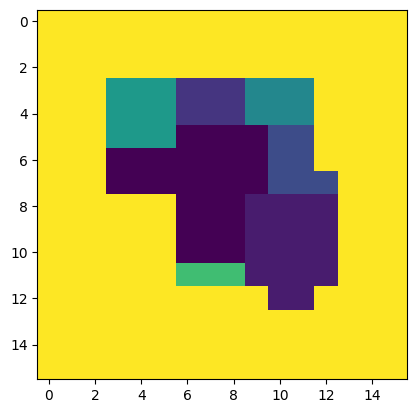

In [32]:
import numpy as np
from matplotlib import pyplot as plt

np.array(selected_file["functions"])

plt.imshow(selected_file["functions"])
plt.show()



---

That't it for RAG with a custom Dataset!

**Happy experimenting!**
